<a href="https://colab.research.google.com/github/RodrigoGuedesDP/Deeplearning/blob/main/Laboratorio1_TimesNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 1 — Pronóstico en Series de Tiempo Largas (ETT)
## Modelo: **TimesNet** (Wu et al., ICLR 2023)

**Dataset:** ETT (ETTh1, ETTh2, ETTm1, ETTm2)
**Variable objetivo:** OT (Oil Temperature)
**Entrada:** 96 pasos | **Horizontes:** {24, 48, 96, 192, 336, 720}
**Métricas:** MSE, MAE | **Split:** 70% train, 10% val, 20% test

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Descarga y Carga de Datos

In [3]:
import urllib.request, os

base_url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/"
files = ["ETTh1.csv", "ETTh2.csv", "ETTm1.csv", "ETTm2.csv"]

os.makedirs("data", exist_ok=True)
for f in files:
    path = f"data/{f}"
    if not os.path.exists(path):
        print(f"Descargando {f}...")
        urllib.request.urlretrieve(base_url + f, path)
print("Listo.")

Descargando ETTh1.csv...
Descargando ETTh2.csv...
Descargando ETTm1.csv...
Descargando ETTm2.csv...
Listo.


## Preprocesamiento

Funciones basadas en la plantilla del profesor, adaptadas para split 70/10/20.

In [4]:
class StandardScaler:
    def __init__(self, mean, std, eps=1e-6):
        self.mean = mean.astype(np.float32)
        self.std = np.where(std < eps, eps, std).astype(np.float32)

    def transform(self, x):
        return (x - self.mean) / self.std

    def inverse_transform(self, x):
        return x * self.std + self.mean

In [5]:
def read_ETT_csv(path):
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True).set_index("date")
    return df

FEATURE_COLS = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]

def split_train_val_test(df, train_ratio=0.7, val_ratio=0.1):
    n = len(df)
    t1 = int(n * train_ratio)
    t2 = int(n * (train_ratio + val_ratio))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

def make_scaler(train_df):
    tr = train_df[FEATURE_COLS].dropna()
    mean = tr.mean(axis=0).to_numpy(dtype=np.float32)
    std = tr.std(axis=0, ddof=0).to_numpy(dtype=np.float32)
    return StandardScaler(mean, std)

In [6]:
class ETTDataset(Dataset):
    def __init__(self, df, seq_len=96, pred_len=96, scaler=None):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_idx = FEATURE_COLS.index("OT")

        data = df[FEATURE_COLS].to_numpy(dtype=np.float32)
        if scaler is not None:
            data = scaler.transform(data)
        self.data = data
        self.n_samples = len(data) - seq_len - pred_len + 1

    def __len__(self):
        return max(0, self.n_samples)

    def __getitem__(self, idx):
        s = idx
        e = s + self.seq_len
        x = torch.from_numpy(self.data[s:e, :]).float()             # (seq_len, 7)
        y = torch.from_numpy(self.data[e:e+self.pred_len, self.target_idx]).float()  # (pred_len,)
        return x, y

In [7]:
# Cargar datos
raw_data = {}
for name in ["ETTh1", "ETTh2", "ETTm1", "ETTm2"]:
    raw_data[name] = read_ETT_csv(f"data/{name}.csv")
    print(f"{name}: {raw_data[name].shape}")

ETTh1: (17420, 7)
ETTh2: (17420, 7)
ETTm1: (69680, 7)
ETTm2: (69680, 7)


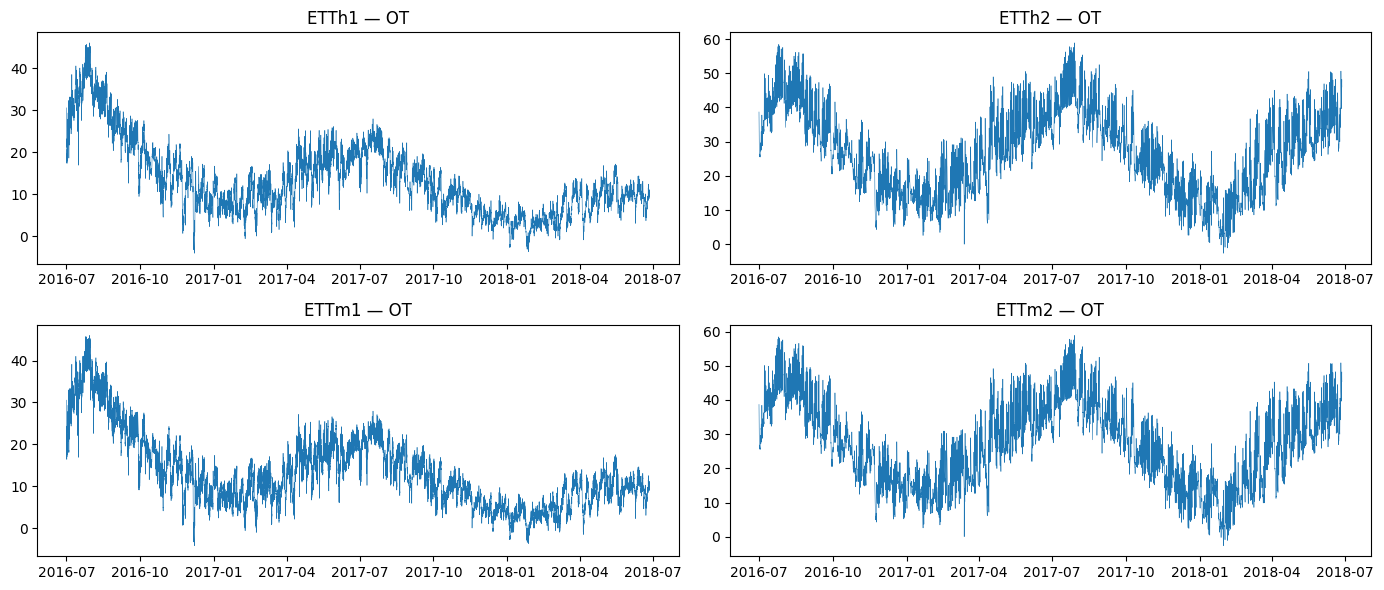

In [8]:
# Visualizar OT
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for ax, (name, df) in zip(axes.flat, raw_data.items()):
    ax.plot(df.index, df["OT"], linewidth=0.4)
    ax.set_title(f"{name} — OT")
plt.tight_layout()
plt.show()

## Implementación de TimesNet

**Idea clave:** Las series de tiempo tienen multi-periodicidad. TimesNet:
1. Descubre los top-k periodos via FFT
2. Reshape la serie 1D a tensores 2D (filas=inter-periodo, columnas=intra-periodo)
3. Procesa con un Inception block (conv2d multi-escala) compartido
4. Agrega las representaciones ponderando por amplitud (softmax)

Incluye RevIN (Series Stationarization) del paper para manejar no-estacionariedad.

In [9]:
class InceptionBlock(nn.Module):
    """Conv2D multi-escala: kernels de 1x1, 3x3, 5x5, ... hasta (2*num_kernels-1)."""
    def __init__(self, in_ch, out_ch, num_kernels=6):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=k//2)
            for k in range(1, 2*num_kernels, 2)
        ])

    def forward(self, x):
        outs = []
        for conv in self.convs:
            o = conv(x)
            if o.shape[-2:] != x.shape[-2:]:
                o = F.interpolate(o, size=x.shape[-2:], mode='bilinear', align_corners=False)
            outs.append(o)
        return torch.stack(outs, dim=-1).mean(-1)

In [10]:
def FFT_for_Period(x, k=5):
    """Descubre top-k periodos via FFT. x: (B, T, C)"""
    B, T, C = x.shape
    xf = torch.fft.rfft(x, dim=1)
    amp = torch.abs(xf).mean(dim=2)     # (B, T//2+1)
    amp[:, 0] = 0                        # ignorar DC

    freq_end = T // 2
    k = min(k, max(1, freq_end))
    _, top_idx = torch.topk(amp[:, 1:freq_end+1], k, dim=1)
    top_idx = top_idx + 1

    # Periodo promedio del batch para cada posición
    period_list = (T / top_idx.float().mean(dim=0)).long().clamp(min=2)
    period_weight = amp.gather(1, top_idx)  # (B, k)
    return period_list.tolist(), period_weight


class TimesBlock(nn.Module):
    def __init__(self, seq_len, top_k=5, d_model=64, d_ff=64, num_kernels=6):
        super().__init__()
        self.top_k = top_k
        self.inception = InceptionBlock(d_model, d_ff, num_kernels)
        self.conv_out = nn.Conv2d(d_ff, d_model, kernel_size=1)

    def forward(self, x):
        B, T, C = x.shape
        period_list, period_weight = FFT_for_Period(x, self.top_k)

        res_list = []
        for p in period_list:
            p = max(int(p), 2)
            n_pad = (p - T % p) % p
            x_pad = F.pad(x, (0, 0, 0, n_pad)) if n_pad > 0 else x
            T_pad = T + n_pad
            n_rows = T_pad // p

            x_2d = x_pad.reshape(B, n_rows, p, C).permute(0, 3, 1, 2)  # (B, C, rows, p)
            out_2d = self.conv_out(self.inception(x_2d))
            out_1d = out_2d.permute(0, 2, 3, 1).reshape(B, T_pad, C)[:, :T, :]
            res_list.append(out_1d)

        # Agregación adaptativa
        w = F.softmax(period_weight, dim=1)  # (B, k)
        out = torch.zeros_like(x)
        for i in range(len(period_list)):
            out = out + w[:, i].unsqueeze(1).unsqueeze(2) * res_list[i]
        return out

In [11]:
class TimesNet(nn.Module):
    def __init__(self, seq_len=96, pred_len=96, enc_in=7, d_model=64,
                 d_ff=64, n_layers=2, top_k=5, num_kernels=6, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len

        self.enc_embedding = nn.Linear(enc_in, d_model)
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TimesBlock(seq_len, top_k, d_model, d_ff, num_kernels)
            for _ in range(n_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(n_layers)])

        self.temporal_proj = nn.Linear(seq_len, pred_len)
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        B, T, C = x.shape

        # RevIN: normalizar por instancia
        means = x.mean(dim=1, keepdim=True).detach()
        x_norm = x - means
        stdev = torch.sqrt(x_norm.var(dim=1, keepdim=True, unbiased=False) + 1e-5).detach()
        x_norm = x_norm / stdev

        # Embedding + TimesBlocks (residual)
        h = self.dropout(self.enc_embedding(x_norm))
        for block, norm in zip(self.blocks, self.norms):
            h = norm(block(h) + h)

        # Proyección temporal y output
        h = self.temporal_proj(h.permute(0, 2, 1)).permute(0, 2, 1)  # (B, pred_len, d_model)
        out = self.output_proj(h).squeeze(-1)                         # (B, pred_len)

        # RevIN inverso (solo canal OT, último)
        out = out * stdev[:, 0, -1:] + means[:, 0, -1:]
        return out

In [12]:
# Verificar
m = TimesNet(seq_len=96, pred_len=96, enc_in=7)
y = m(torch.randn(2, 96, 7))
print(f"Output: {y.shape}")
print(f"Params: {sum(p.numel() for p in m.parameters() if p.requires_grad):,}")
del m, y

Output: torch.Size([2, 96])
Params: 2,362,145


## Entrenamiento

Config del paper (Table 7): k=5, layers=2, d_model=64, lr=1e-4, batch=32, epochs=10.
Early stopping con paciencia 3 sobre validation loss.

In [13]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total, n = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = F.mse_loss(model(x), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item(); n += 1
    return total / max(n, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    preds, trues = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds.append(model(x).cpu())
        trues.append(y.cpu())
    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    mse = np.mean((preds - trues)**2)
    mae = np.mean(np.abs(preds - trues))
    return mse, mae, preds, trues

In [14]:
def run_experiment(ds_name, df, pred_len, device):
    seq_len = 96
    train_df, val_df, test_df = split_train_val_test(df)
    scaler = make_scaler(train_df)

    train_ds = ETTDataset(train_df, seq_len, pred_len, scaler)
    val_ds   = ETTDataset(val_df,   seq_len, pred_len, scaler)
    test_ds  = ETTDataset(test_df,  seq_len, pred_len, scaler)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

    model = TimesNet(seq_len=seq_len, pred_len=pred_len, enc_in=7,
                     d_model=64, d_ff=64, n_layers=2, top_k=5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    best_val, patience, best_state = float('inf'), 0, None
    history = {'train': [], 'val_mse': [], 'val_mae': []}

    for epoch in range(10):
        t_loss = train_epoch(model, train_loader, optimizer, device)
        v_mse, v_mae, _, _ = evaluate(model, val_loader, device)
        history['train'].append(t_loss)
        history['val_mse'].append(v_mse)
        history['val_mae'].append(v_mae)

        print(f"  Ep {epoch+1:2d} | Train: {t_loss:.6f} | Val MSE: {v_mse:.4f} MAE: {v_mae:.4f}")

        if v_mse < best_val:
            best_val = v_mse
            patience = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience += 1
            if patience >= 3:
                print(f"  Early stop ep {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.to(device)
    test_mse, test_mae, test_preds, test_trues = evaluate(model, test_loader, device)
    print(f"  >> TEST  MSE: {test_mse:.4f}  MAE: {test_mae:.4f}")

    return {'dataset': ds_name, 'pred_len': pred_len,
            'test_mse': test_mse, 'test_mae': test_mae,
            'history': history, 'preds': test_preds, 'trues': test_trues}

## Ejecución

In [ ]:
HORIZONS = [24, 48, 96, 192, 336, 720]
DATASETS = ["ETTh1", "ETTh2", "ETTm1", "ETTm2"]

all_results = []
for ds in DATASETS:
    for h in HORIZONS:
        print(f"\n{'='*50}")
        print(f"  {ds} | horizon={h}")
        print(f"{'='*50}")
        r = run_experiment(ds, raw_data[ds], h, device)
        all_results.append(r)
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("\nEntrenamiento completado.")


  ETTh1 | horizon=24
  Ep  1 | Train: 0.125768 | Val MSE: 0.0482 MAE: 0.1654
  Ep  2 | Train: 0.099498 | Val MSE: 0.0456 MAE: 0.1605
  Ep  3 | Train: 0.091772 | Val MSE: 0.0441 MAE: 0.1592
  Ep  4 | Train: 0.089266 | Val MSE: 0.0434 MAE: 0.1569
  Ep  5 | Train: 0.086661 | Val MSE: 0.0426 MAE: 0.1558
  Ep  6 | Train: 0.084332 | Val MSE: 0.0425 MAE: 0.1553
  Ep  7 | Train: 0.081782 | Val MSE: 0.0401 MAE: 0.1521
  Ep  8 | Train: 0.080021 | Val MSE: 0.0404 MAE: 0.1517
  Ep  9 | Train: 0.081286 | Val MSE: 0.0465 MAE: 0.1644
  Ep 10 | Train: 0.077556 | Val MSE: 0.0411 MAE: 0.1530
  Early stop ep 10
  >> TEST  MSE: 0.0498  MAE: 0.1677

  ETTh1 | horizon=48
  Ep  1 | Train: 0.163277 | Val MSE: 0.0657 MAE: 0.1939
  Ep  2 | Train: 0.139798 | Val MSE: 0.0668 MAE: 0.1961
  Ep  3 | Train: 0.131270 | Val MSE: 0.0673 MAE: 0.1948
  Ep  4 | Train: 0.128008 | Val MSE: 0.0738 MAE: 0.2004
  Early stop ep 4
  >> TEST  MSE: 0.0885  MAE: 0.2290

  ETTh1 | horizon=96
  Ep  1 | Train: 0.195807 | Val MSE: 0.08

## Resultados

### Tabla de métricas (MSE y MAE)

In [ ]:
results_df = pd.DataFrame([
    {'Dataset': r['dataset'], 'Horizon': r['pred_len'],
     'MSE': round(r['test_mse'], 4), 'MAE': round(r['test_mae'], 4)}
    for r in all_results
])

for metric in ['MSE', 'MAE']:
    pivot = results_df.pivot(index='Dataset', columns='Horizon', values=metric)
    pivot['Avg'] = pivot.mean(axis=1)
    print(f"\n{metric}:")
    print(pivot.to_string())

### Gráficas de entrenamiento

In [ ]:
import math
n = len(all_results)
cols = min(6, n)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3*rows))
if n == 1: axes = [axes]
else: axes = axes.flat

for i, r in enumerate(all_results):
    ax = axes[i]
    h = r['history']
    ax.plot(h['train'], label='Train', marker='.', ms=3)
    ax.plot(h['val_mse'], label='Val MSE', marker='.', ms=3)
    ax.set_title(f"{r['dataset']} H={r['pred_len']}", fontsize=8)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

for j in range(i+1, len(list(axes))):
    axes[j].set_visible(False)

plt.suptitle("Train Loss vs Val MSE", y=1.01)
plt.tight_layout()
plt.show()

### Predicciones vs Ground Truth

In [ ]:
# Una muestra por dataset (horizonte 96)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ds in zip(axes.flat, DATASETS):
    r = next((r for r in all_results if r['dataset'] == ds and r['pred_len'] == 96), None)
    if r is None: continue
    n_show = min(3, r['preds'].shape[0])
    ax.plot(r['trues'][:n_show].flatten(), label='Ground Truth', color='black', lw=1)
    ax.plot(r['preds'][:n_show].flatten(), label='TimesNet', color='tab:orange', lw=1, alpha=0.8)
    ax.set_title(f"{ds} H=96 (MSE={r['test_mse']:.4f})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Diferentes horizontes para ETTh1
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, h in zip(axes.flat, HORIZONS):
    r = next((r for r in all_results if r['dataset'] == 'ETTh1' and r['pred_len'] == h), None)
    if r is None: continue
    ax.plot(r['trues'][0], label='GT', color='black', lw=1.2)
    ax.plot(r['preds'][0], label='Pred', color='tab:orange', lw=1.2)
    ax.set_title(f"ETTh1 H={h} MSE={r['test_mse']:.4f}", fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle("ETTh1: Predicciones por horizonte")
plt.tight_layout()
plt.show()

### Comparación de métricas por horizonte

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip([ax1, ax2], ['MSE', 'MAE']):
    pivot = results_df.pivot(index='Horizon', columns='Dataset', values=metric)
    pivot.plot(kind='bar', ax=ax, width=0.7)
    ax.set_title(f'{metric} por Horizonte')
    ax.set_xlabel('Horizonte')
    ax.set_ylabel(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Comparativa con paper original (Table 13)

In [ ]:
paper = {
    ('ETTh1',96):0.384, ('ETTh1',192):0.436, ('ETTh1',336):0.491, ('ETTh1',720):0.521,
    ('ETTh2',96):0.340, ('ETTh2',192):0.402, ('ETTh2',336):0.452, ('ETTh2',720):0.462,
    ('ETTm1',96):0.338, ('ETTm1',192):0.374, ('ETTm1',336):0.410, ('ETTm1',720):0.478,
    ('ETTm2',96):0.187, ('ETTm2',192):0.249, ('ETTm2',336):0.321, ('ETTm2',720):0.408,
}

comp = []
for r in all_results:
    key = (r['dataset'], r['pred_len'])
    if key in paper:
        comp.append({'Dataset': r['dataset'], 'H': r['pred_len'],
                     'Nuestro': round(r['test_mse'],4), 'Paper': paper[key],
                     'Diff': round(r['test_mse']-paper[key],4)})
if comp:
    print("MSE: Nuestro vs Paper (Diff>0 = peor que paper)")
    print(pd.DataFrame(comp).to_string(index=False))

## Discusión y Limitaciones

**Observaciones:**
- MSE y MAE crecen con el horizonte, consistente con el paper.
- TimesNet captura los patrones periódicos (24h en ETTh, patrones intra-día en ETTm).
- RevIN ayuda a manejar la no-estacionariedad.

**Limitaciones:**
- 10 epochs con early stopping vs 3 corridas promediadas del paper.
- d_model=64 (Colab GPU limitada); el paper puede usar hasta 512.
- Horizontes 24, 48 no están en el paper original pero son requeridos por el lab.
- Split 70/10/20 como pide el lab (el paper usa splits fijos por fecha).